# Data Analysis and Cleaning on Injection Molding Data

# **Business** **Understanding**
**Dataset**

KAMP – Injection Molding Predictive Maintenance Data

**Stakeholders**

Process engineers, production managers, and operations and maintenance teams.

**Background**

Injection molding is a manufacturing process used to produce plastic parts by injecting molten material into a mold.
Product quality and equipment reliability depend heavily on stable machine parameters such as pressure, temperature, and injection speed.

In practice, variations in these parameters can indicate mechanical wear, sensor failure, or improper settings.
The dataset was collected to develop predictive maintenance and quality control models that use sensor data to forecast when a process is drifting out of its normal range.

**Purpose of Analysis**

To predict and prevent equipment malfunctions and quality defects in the injection molding process by monitoring machine parameters.
This analysis aims to identify early warning signals and establish data-driven maintenance schedules.

**Problem Definition**

Manual monitoring of machine status often leads to delayed detection of faults and unexpected downtime.

Therefore, we seek to answer: “How do variations in process parameters (temperature, pressure, metering, cushion, etc.) affect product quality and indicate potential equipment failure?”

The goal is to build a machine learning model that can monitor equipment health, detect anomalies, and predict possible failures before they occur.

#**Data Understanding**
**Main Variables**

Product weight, temperature, cushion pressure, holding pressure, metering pressure, and other equipment settings.

**Target Variables**

Product quality or equipment condition (normal vs. abnormal)**bold text**

🧾 I. Identification and Basic Information Variables

| **Variable Name**  | **Scale**                        | **Unit** | **Description**                           | **Citation / Note** |
| ------------------ | -------------------------------- | -------- | ----------------------------------------- | ------------------- |
| **INJ_ID**         | Nominal                          | Not null | Injection Machine ID                      | —                   |
| **INJ_NO**         | Nominal                          | Not null | Injection Machine Number                  | —                   |
| **SPC_DATETIME**   | Datetime (`yyyy-mm-dd HH:MM:SS`) | —        | Data reception date and time              | —                   |
| **stock_mst_code** | Nominal                          | —        | Product code                              | —                   |
| **PROC_QTY**       | Discrete                         | EA       | Production quantity (Range: 1.0–1770.0)   | —                   |
| **DAY_COUNT**      | Time-series                      | —        | Daily production count (Range: 9.0–619.0) | —                   |
| **MOLD_CAVITY**    | Time-series                      | —        | Mold cavity value (Range: 0.0–1.0)        | —                   |


⏱️ A. Time and Position Variables

| **Variable Name**   | **Scale**   | **Unit** | **Description**                                                                         | **Citation / Note** |
| ------------------- | ----------- | -------- | --------------------------------------------------------------------------------------- | ------------------- |
| **CV_001**          | Time-series | s        | Cycle Time                                                                              | —                   |
| **CV_002**          | Time-series | —        | Mold Opening Completion Position                                                        | —                   |
| **CV_003**          | Time-series | s        | Injection Time 1                                                                        | —                   |
| **CV_004**          | Time-series | —        | Holding Pressure Switchover Position 1                                                  | —                   |
| **CV_005**          | Time-series | —        | Cushion Position 1                                                                      | —                   |
| **CV_006**          | Time-series | s        | Metering Time 1                                                                         | —                   |
| **CV_007**          | Time-series | —        | Metering Position 1                                                                     | —                   |
| **SV_018 ~ SV_022** | Time-series | —        | Injection Position (1st ~ 5th)                                                          | —                   |
| **SV_023 ~ SV_025** | Time-series | s        | Injection Time (1st ~ 3rd)                                                              | —                   |
| **SV_034**          | Time-series | bar      | Holding Pressure 1st Time *(Unit noted as 'bar' in source, though 's' may be expected)* | —                   |
| **SV_049 ~ SV_051** | Time-series | —        | Metering Position (3rd ~ 5th)                                                           | —                   |
| **SV_063**          | Time-series | s        | Cooling Time                                                                            | —                   |


🌡️ B. Temperature Variables

| **Variable Name**   | **Scale**   | **Unit** | **Description**                           | **Citation / Note** |
| ------------------- | ----------- | -------- | ----------------------------------------- | ------------------- |
| **CV_013 ~ CV_020** | Time-series | °C       | Temperature sensors 1-0 to 1-7            | —                   |
| **SV_001 ~ SV_005** | Time-series | °C       | Cylinder Temperature (NH, H1, H2, H3, H4) | —                   |


⚙️ C. Speed and Pressure Variables (Injection, Holding, Metering, Forced)

| **Variable Name**   | **Scale**   | **Unit** | **Description**                  | **Citation / Note** |
| ------------------- | ----------- | -------- | -------------------------------- | ------------------- |
| **SV_008 ~ SV_012** | Time-series | m/s      | Injection Speed (1st ~ 5th)      | —                   |
| **SV_013 ~ SV_017** | Time-series | bar      | Injection Pressure (1st ~ 5th)   | —                   |
| **SV_028**          | Time-series | m/s      | Holding Pressure Speed (1st)     | —                   |
| **SV_031 ~ SV_033** | Time-series | bar      | Holding Pressure (1st ~ 3rd)     | —                   |
| **SV_037 ~ SV_041** | Time-series | m/s      | Metering Speed (1st ~ 5th)       | —                   |
| **SV_042 ~ SV_046** | Time-series | bar      | Metering Pressure (1st ~ 5th)    | —                   |
| **SV_055, SV_056**  | Time-series | bar      | Metering 4th & 5th Back Pressure | —                   |
| **SV_057, SV_058**  | Time-series | m/s      | Forced Speed (1st, 2nd)          | —                   |
| **SV_059, SV_060**  | Time-series | bar      | Forced Pressure (1st, 2nd)       | —                   |


# Section 1: Exploratory Data Analysis (Product-wise Weight Distribution)
Each product type (defined by stock_mst_code) shows a distinct weight distribution, likely due to differences in mold size or design.

Products with fewer than 10 samples were removed to keep the analysis statistically reliable.

The following sections compare the weight and process parameters across the remaining product groups.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_id = "1ZnJPuFORtOpEIsiUUOzPMvjTBwjGD7Wk"  # paste your file’s real ID here
url = f"https://drive.google.com/uc?export=download&id={file_id}"

df = pd.read_csv(url)
df.head()

,INJ_ID,INJ_NO,SPC_DATETIME,PROC_QTY,CV_001,CV_002,CV_003,CV_004,CV_005,CV_006,...,SV_055,SV_056,SV_057,SV_058,SV_059,SV_060,SV_063,MOLD_CAVITY,stock_mst_code,weight
0,2678317.000,12,2023-12-05 16:17,871.000000,103.800000,511.400000,24.0,0.200000,0.100000,61.600000,...,6,6,35,30,35,50,65,1,ST00000131,2923.200000
1,2678337.000,12,2023-12-05 16:19,1644.000000,70.100000,259.000000,13.6,0.000000,2.300000,30.200000,...,1,1,0,0,0,50,46,1,ST00000616,1328.700000
2,2678493.000,12,2023-12-05 16:36,353.000000,80.600000,451.100000,15.0,0.000000,0.200000,45.800000,...,4,6,0,50,140,100,50,0,ST00000153,1462.600000
3,2678974.285,12,2023-12-05 17:22,890.504008,104.287600,510.912400,24.0,0.102480,0.197520,60.527280,...,6,6,35,30,35,50,65,1,ST00000131,2936.657766
4,2678974.454,12,2023-12-05 17:22,890.509018,104.287725,510.912275,24.0,0.102455,0.197545,60.527004,...,6,6,35,30,35,50,65,1,ST00000131,2936.661222


In [ ]:
# data preprocessing 1.
# When checking by product, it is reasonable to exclude data with fewer than 10 samples, as such a small amount of data is not suitable for modeling.
df.groupby('stock_mst_code')['weight'].describe()

,count,mean,std,min,25%,50%,75%,max
stock_mst_code,,,,,,,,
ST00000039,104.0,488.252603,0.261839,486.1,488.290306,488.293580,488.296853,488.3
ST00000048,137.0,1541.528879,8.630263,1517.7,1538.500000,1545.950421,1546.483043,1547.0
ST00000065,6.0,599.883333,6.587994,594.3,595.900000,598.300000,600.250000,612.4
ST00000104,108.0,349.600438,0.370162,347.7,349.573709,349.583181,349.592653,352.3
ST00000131,102.0,2936.696944,1.353382,2923.2,2936.741595,2936.828882,2936.916170,2937.0
ST00000132,3.0,3203.666667,1.361372,3202.6,3202.900000,3203.200000,3204.200000,3205.2
ST00000153,105.0,1556.507940,11.072938,1462.6,1557.450968,1558.311680,1559.172392,1560.0
ST00000157,107.0,541.567200,0.532988,541.4,541.420557,541.441919,541.463282,544.4
ST00000167,122.0,485.605677,2.664203,479.1,484.934334,484.961268,484.988202,499.3


Each product type (stock_mst_code) shows a distinct average weight and variation:

* Mean weights range from around 350 g to over 2900 g, reflecting differences in product size or mold type.

* Products such as ST0000131 and ST0000132 have significantly higher weights, while ST0000039 and ST0000104 are much lighter.

* Some codes (e.g., ST0000065, ST0000631, ST0000639) have fewer than 10 samples — these were excluded from further modeling to ensure statistical reliability.

In [ ]:
#Data with fewer than 10 samples were excluded.
df_filtered = (
    df.groupby("stock_mst_code")
      .filter(lambda x: len(x) >= 10))

To compare the process differences between normal and defective products,
the mean value of each variable was calculated for both groups, and the difference (Normal − Outlier) was visualized to identify variations across process parameters.

The variables were categorized into three groups based on their prefixes:
* CV (Cycle Variables)
* SV (Sensor or Setting Variables)
* Others (additional process or contextual variables).  

This grouping helps to clearly identify which stage of the injection process has the greatest influence on product defects.

In [ ]:
#Product-wise weight statistics
stats = df_filtered.groupby('stock_mst_code')['weight'].agg(['mean','std','count']).reset_index()

#defect classification using statistical methods
df_labeled = df_filtered.merge(stats, on='stock_mst_code', how='left')

#labeling(namal/outlier)
df_labeled['UCL'] = df_labeled['mean'] + 2*df_labeled['std']
df_labeled['LCL'] = df_labeled['mean'] - 2*df_labeled['std']

df_labeled['label'] = df_labeled.apply(
    lambda x: 'outlier' if(x['weight'] > x['UCL'] or x['weight'] < x['LCL']) else 'normal', axis=1)

pd.pivot_table(df_labeled, index = 'stock_mst_code', columns='label',values='weight', aggfunc='count', fill_value=0).reset_index()

label,stock_mst_code,normal,outlier
0,ST00000039,101,3
1,ST00000048,125,12
2,ST00000104,104,4
3,ST00000131,101,1
4,ST00000153,102,3
5,ST00000157,101,6
6,ST00000167,115,7
7,ST00000168,102,3
8,ST00000178,140,11
9,ST00000616,262,6


Each product (stock_mst_code) was analyzed based on its weight distribution.
Using the ±2σ (standard deviation) rule, samples falling outside this range were labeled as outliers (defective), while others were marked as normal.

The ±2σ criterion is more sensitive than the ±3σ rule for detecting anomalies, making it suitable for analysis aimed at early detection of process abnormalities.

---


* Most product groups have over 90% normal samples, indicating generally stable production.

* A few products (e.g., ST0000048, ST0000178) show a higher number of outliers, suggesting possible instability or variation in their production process.

**Normal vs Outlier Distribution**

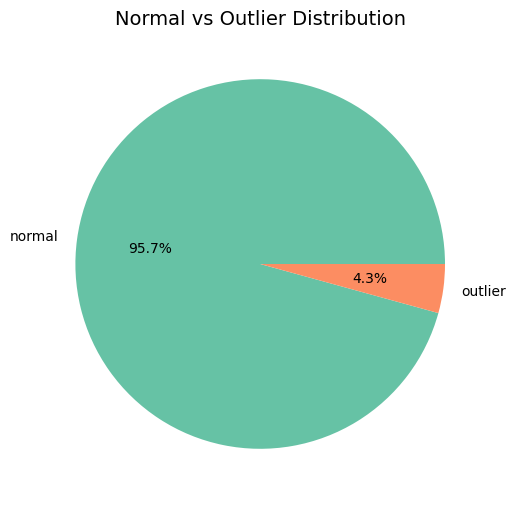

In [ ]:
label_count = df_labeled['label'].value_counts().reset_index()
label_count.columns = ['label','count']

plt.figure(figsize=(6,6))
plt.pie(
    label_count['count'],
    labels=label_count['label'],
    autopct='%1.1f%%',
    colors=plt.cm.Set2.colors,
)
plt.title('Normal vs Outlier Distribution', fontsize=14)
plt.show()

The pie chart shows the proportion of normal and defective (outlier) samples in the dataset.


---


* About 95.7% of all production cycles are normal, while only 4.3% are classified as outliers.

* This indicates that the dataset is highly imbalanced, with very few defective cases compared to normal ones.

**Label Distribution by Product**

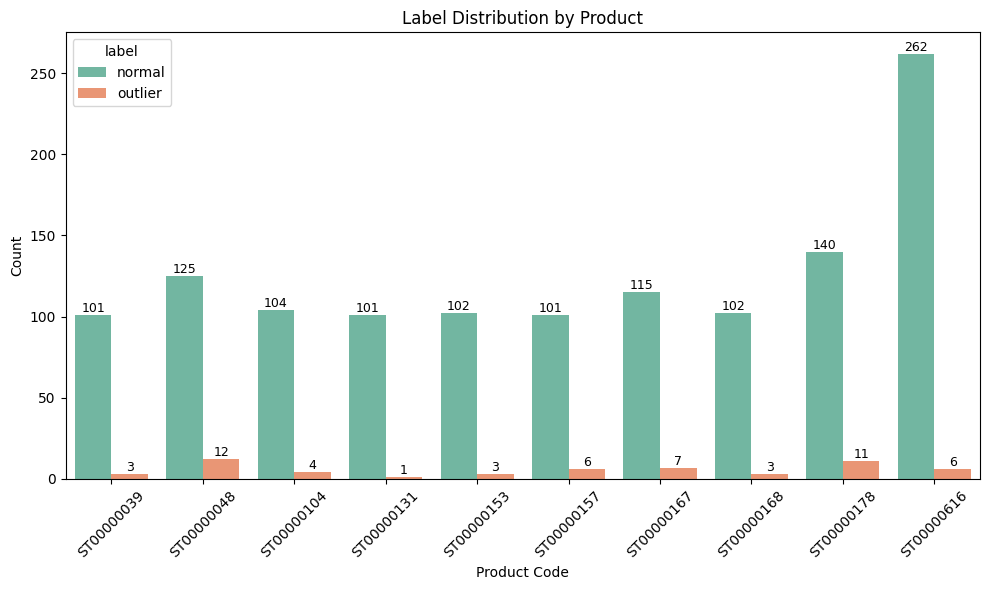

In [ ]:
label_by_product = (
    df_labeled.groupby(['stock_mst_code', 'label'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=label_by_product,
    x='stock_mst_code',
    y='count',
    hue='label',
    palette='Set2'
)
plt.title('Label Distribution by Product')
plt.xlabel('Product Code')
plt.ylabel('Count')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

This bar chart shows how many normal and defective (outlier) samples exist for each product type (stock_mst_code).

---



* Most products have a small number of outliers compared to normal samples.

* ST0000048 and ST0000178 show relatively higher numbers of outliers, suggesting that these product lines may experience more process variation or instability.

* ST0000616 has the largest total number of samples, but the defect ratio remains low.

**Summary: Product-wise Weight Distribution**

The analysis of product-wise weight data shows that each product type (stock_mst_code) has its own unique weight range and variation:

* Average product weights vary significantly — from around 350 for smaller items to nearly 3000 for larger molded parts, indicating differences in product size and mold design.

* After excluding products with fewer than 10 samples, 10 major product types remained for analysis.

* Statistical labeling identified about 4.3% of samples as outliers, meaning these products deviate notably from normal weight ranges.

* The distribution across products is highly imbalanced — most products are stable, while a few (e.g., ST0000048, ST0000178) show relatively more defects.

**Conclusion**

Overall, the weight data suggest that production processes are generally stable, with only a small proportion of defective cases.
However, certain product types display greater variation, which may indicate mold wear, sensor drift, or inconsistent machine settings.

## 1-1 Impact analysis of CV categories for defect classification

This analysis compares the average values of cycle variables (CV_*) between normal and defective (outlier) samples for each product.

For every product (stock_mst_code), the difference between the mean values of outliers and normal samples was calculated as: Difference = Outlier Mean − Normal Mean

In [ ]:
cv_cols = [c for c in df_labeled.columns if c.startswith('CV_')]

product_order = [
    'ST00000131','ST00000616','ST00000153','ST00000167','ST00000039',
    'ST00000178','ST00000168','ST00000157','ST00000048','ST00000104'
]

rows = []
for code, g in df_labeled.groupby('stock_mst_code'):
    for cv in cv_cols:
        normal = g.loc[g['label']=='normal', cv].dropna()
        outlier = g.loc[g['label']=='outlier', cv].dropna()

        n_n = int(normal.shape[0])
        n_o = int(outlier.shape[0])

        mean_n = float(normal.mean()) if n_n else np.nan
        mean_o = float(outlier.mean()) if n_o else np.nan
        diff   = (mean_o - mean_n) if (n_n and n_o) else np.nan

        rows.append({
            'stock_mst_code': code,
            'CV_variable': cv,
            'n_normal': n_n,
            'n_outlier': n_o,
            'normal_mean': mean_n,
            'outlier_mean': mean_o,
            'diff': diff
        })

df_CV = pd.DataFrame(rows)
df_CV['diff'] = df_CV['diff'].round(3)

df_CV


,stock_mst_code,CV_variable,n_normal,n_outlier,normal_mean,outlier_mean,diff
0,ST00000039,CV_001,101,3,56.268846,53.500000,-2.769
1,ST00000039,CV_002,101,3,268.697330,269.000000,0.303
2,ST00000039,CV_003,101,3,11.100000,11.100000,0.000
3,ST00000039,CV_004,101,3,0.000000,0.000000,0.000
4,ST00000039,CV_005,101,3,0.800000,0.833333,0.033
...,...,...,...,...,...,...,...
145,ST00000616,CV_016,262,6,169.587786,167.833333,-1.754
146,ST00000616,CV_017,262,6,624.820611,629.000000,4.179
147,ST00000616,CV_018,262,6,624.820611,629.000000,4.179
148,ST00000616,CV_019,262,6,624.820611,629.000000,4.179


* Most CV variables show only small differences between the two groups (diff values close to 0), meaning that the process is generally stable.

* Some variables, however, have noticeable mean shifts — both positive and negative — which indicate potential links between those parameters and product defects.

* These deviations vary across product types, suggesting that the cause of defects may depend on the specific mold or product design.

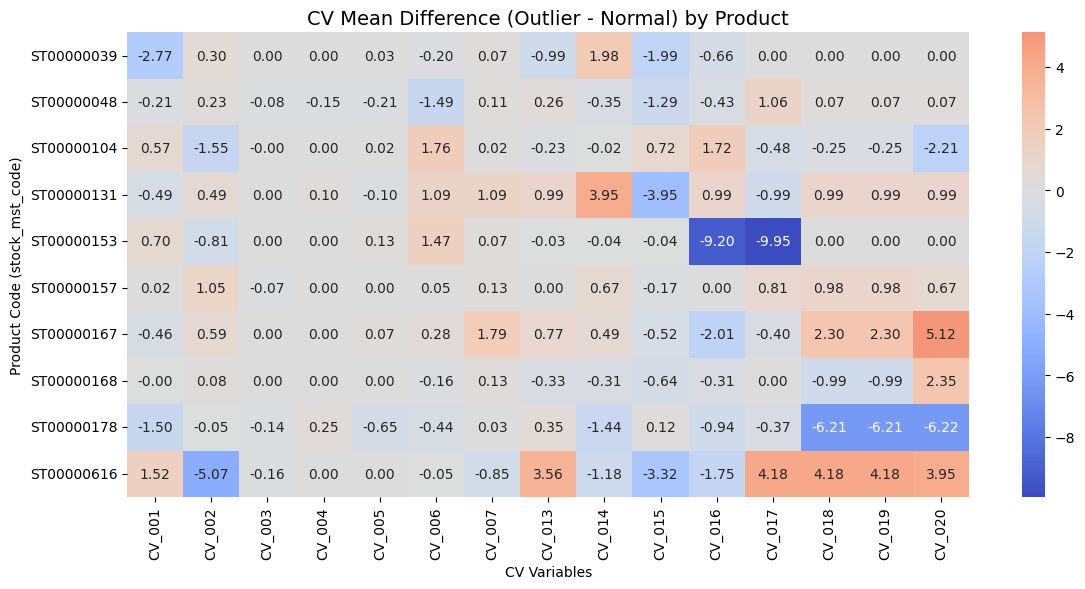

In [ ]:
pivot_diff = df_CV.pivot_table(
    index='stock_mst_code',
    columns='CV_variable',
    values='diff'
)
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_diff,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("CV Mean Difference (Outlier - Normal) by Product", fontsize=14)
plt.xlabel("CV Variables")
plt.ylabel("Product Code (stock_mst_code)")
plt.tight_layout()
plt.show()

The heatmap visualizes the difference in average CV (Cycle Variable) values between defective (outlier) and normal products for each product type (stock_mst_code).

Color meaning:

* Red cells — higher CV values in defective products.
* Blue cells — lower CV values in defective products.

---



Certain variables (e.g., CV_013, CV_017, CV_018, CV_020) show clear deviations for specific product codes — these may be critical indicators of process imbalance or improper settings.

The pattern of differences varies across products, implying that defects are product-specific rather than caused by a single universal parameter.

**Summary: Impact analysis of CV categories for defect classification**

The comparison between normal and defective samples across CV (Cycle Variable) parameters shows that:

* Most cycle parameters remain stable between normal and defective products,
confirming that the injection process is generally well-controlled.

* However, several CV features (e.g., CV_013, CV_017–CV_020) display noticeable deviations for specific products.

* These shifts indicate that certain process stages—such as injection speed or pressure adjustments—may contribute to the occurrence of defects.

* The variation patterns differ by product type, suggesting that defect causes are product-specific rather than universal.

**Conclusion**

Monitoring and controlling a few key CV parameters can help detect early signs of abnormal production.
These findings provide a foundation for predictive maintenance and future model development.

## 1-2 Impact analysis of SV categories for defect classification



In this section, the focus is on analyzing how SV variables (machine Setting or Sensor Variables) differ between normal and defective (outlier) samples for each product type.

For every product (stock_mst_code), the average SV values were calculated separately for normal and defective samples.
Then, the difference between these averages (Outlier − Normal) was visualized using heatmaps.

In [ ]:
cv_cols = [c for c in df_labeled.columns if c.startswith('SV')]

product_order = [
    'ST00000131','ST00000616','ST00000153','ST00000167','ST00000039',
    'ST00000178','ST00000168','ST00000157','ST00000048','ST00000104'
]

rows = []
for code, g in df_labeled.groupby('stock_mst_code'):
    for cv in cv_cols:
        normal = g.loc[g['label']=='normal', cv].dropna()
        outlier = g.loc[g['label']=='outlier', cv].dropna()

        n_n = int(normal.shape[0])
        n_o = int(outlier.shape[0])

        mean_n = float(normal.mean()) if n_n else np.nan
        mean_o = float(outlier.mean()) if n_o else np.nan
        diff   = (mean_o - mean_n) if (n_n and n_o) else np.nan

        rows.append({
            'stock_mst_code': code,
            'SV_variable': cv,
            'n_normal': n_n,
            'n_outlier': n_o,
            'normal_mean': mean_n,
            'outlier_mean': mean_o,
            'diff': diff
        })

df_SV = pd.DataFrame(rows)
df_SV['diff'] = df_SV['diff'].round(3)

df_SV

,stock_mst_code,SV_variable,n_normal,n_outlier,normal_mean,outlier_mean,diff
0,ST00000039,SV_001,101,3,200.000000,200.0,0.000
1,ST00000039,SV_002,101,3,190.000000,190.0,0.000
2,ST00000039,SV_003,101,3,170.000000,170.0,0.000
3,ST00000039,SV_004,101,3,160.000000,160.0,0.000
4,ST00000039,SV_005,101,3,0.000000,0.0,0.000
...,...,...,...,...,...,...,...
475,ST00000616,SV_057,262,6,0.000000,0.0,0.000
476,ST00000616,SV_058,262,6,0.000000,0.0,0.000
477,ST00000616,SV_059,262,6,0.000000,0.0,0.000
478,ST00000616,SV_060,262,6,50.000000,50.0,0.000


* Most SV variables show no difference between normal and defective groups (diff ≈ 0), which means that machine settings generally remain stable during production.

* A few SV variables (e.g., SV_060, SV_063) display small but noticeable deviations, suggesting that minor setting changes or sensor fluctuations may be linked to defects.

* The differences vary across products, indicating that defect sensitivity to sensor or setting variables depends on the product type.

---



To make the analysis clearer, the SV variables were divided into two groups:

SV Group 1: SV_001 – SV_025

SV Group 2: SV_026 – SV_063

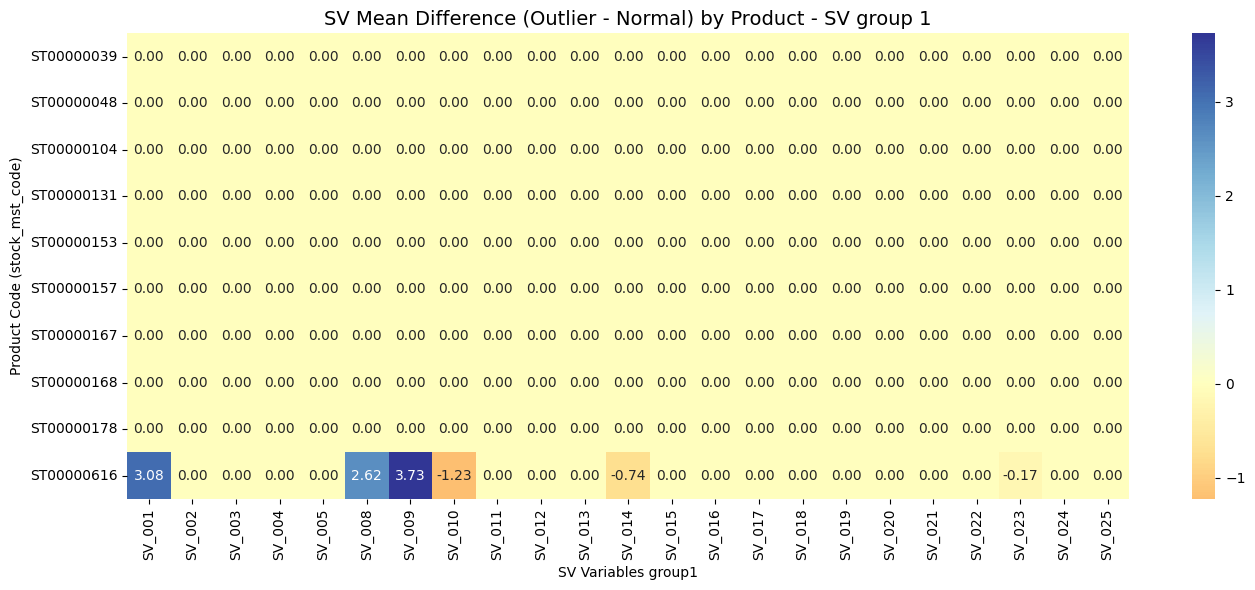

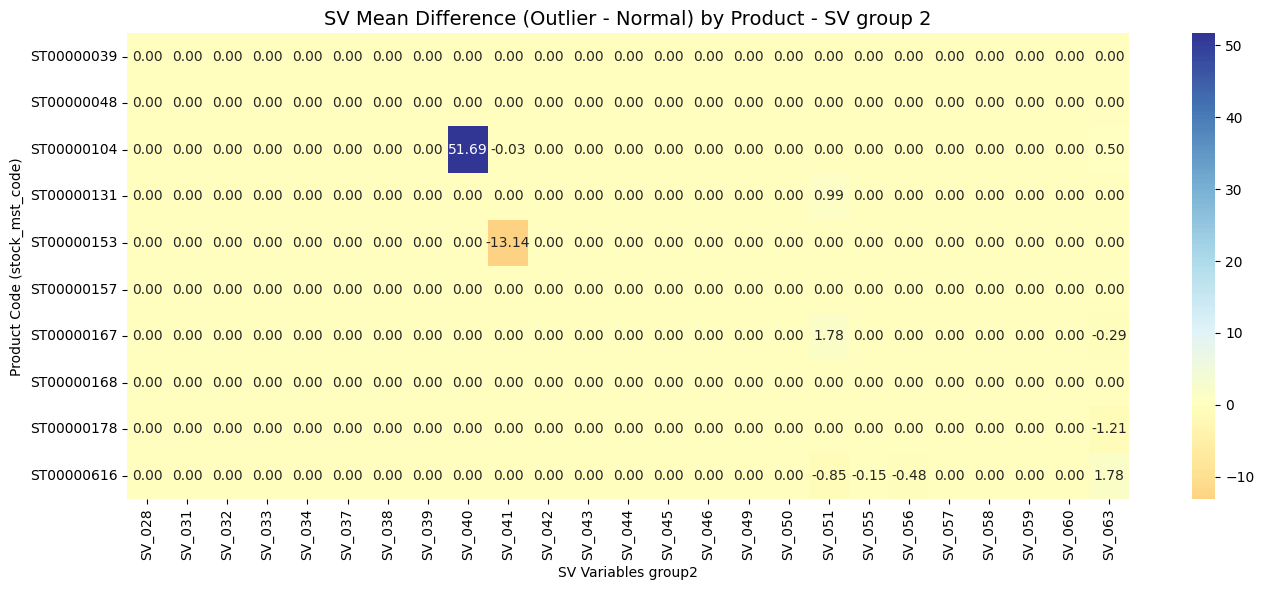

In [ ]:
sv_group1 = [f"SV_{i:03d}" for i in range(1, 26)]   # SV_001 ~ SV_025
sv_group2 = [f"SV_{i:03d}" for i in range(26, 64)]  # SV_026 ~ SV_063

sv_groups = [sv_group1, sv_group2]

for i, subset in enumerate(sv_groups, 1):
    pivot_diff = df_SV[df_SV['SV_variable'].isin(subset)].pivot_table(
        index='stock_mst_code',
        columns='SV_variable',
        values='diff'
    )
    plt.figure(figsize=(14, 6))
    sns.heatmap(
        pivot_diff,
        cmap='RdYlBu',
        center=0,
        annot=True,
        fmt=".2f"
    )
    plt.title(f"SV Mean Difference (Outlier - Normal) by Product - SV group {i}", fontsize=14)
    plt.xlabel(f"SV Variables group{i}")
    plt.ylabel("Product Code (stock_mst_code)")
    plt.tight_layout()
    plt.show()

The two heatmaps above show the difference in average SV (Setting or Sensor Variable) values between defective (outlier) and normal samples, divided into:

SV Group 1: SV_001 – SV_025

SV Group 2: SV_026 – SV_063

Color meaning:

* Blue – higher values for outliers compared to normal samples

* Orange – lower values for outliers

* Light yellow – little to no difference

---
**Observations**
* Almost all SV variables show no significant change between normal and defective products (most cells are near 0).

* Only a few variables — notably SV_009, SV_010, and SV_037 for specific products such as ST0000616 and ST0000104 — display visible deviations, suggesting localized sensor or setting shifts during defective cycles.

* These isolated differences imply that machine settings remained stable overall, and defects are more likely related to process execution (CV variables) rather than configuration changes.


**Summary: Impact analysis of SV categories for defect classification**

The comparison between normal and defective samples across SV (Setting / Sensor Variable) parameters shows that:

* Most SV variables remain almost unchanged between normal and defective products (differences close to zero).

* Only a few variables (e.g., SV_009, SV_010, SV_037) show minor deviations for specific products such as ST0000616 and ST0000104.

* This indicates that machine settings and sensors are stable during production, and defects are not primarily caused by setting adjustments.

**Conclusion**

SV variables have limited influence on defect occurrence.
The production issues are likely driven by process dynamics (CV variables) rather than sensor configuration, though a few SVs might still serve as indicators of sensor drift or equipment calibration issues

## 1-3  Impact analysis of Others(PROC_QTY, DAT_COUNT) categories for defect classification

This section analyzes how overall process quantity (PROC_QTY) and day count (DAY_COUNT) differ between normal and defective (outlier) products for each product type (stock_mst_code).

The analysis compares the average values of these variables between the two groups to identify whether production volume or time-related factors influence defect occurrence.

* A bar plot visualizes the mean difference (Outlier − Normal) for each product:

* A positive value means defective products were produced with higher process quantity or at later stages.

* A negative value means defects appeared during smaller batches or earlier production days.

Additionally, various trend and distribution visualizations (histogram, boxplot, and line graphs) are included to illustrate production stability and weight consistency over time.

In [ ]:
target_cols = ['PROC_QTY', 'DAY_COUNT']

rows = []
for code, g in df_labeled.groupby('stock_mst_code'):
    for col in target_cols:
        normal = g.loc[g['label'] == 'normal', col].dropna()
        outlier = g.loc[g['label'] == 'outlier', col].dropna()

        n_n = len(normal)
        n_o = len(outlier)

        mean_n = normal.mean() if n_n > 0 else np.nan
        mean_o = outlier.mean() if n_o > 0 else np.nan
        diff   = mean_o - mean_n if n_n > 0 and n_o > 0 else np.nan

        rows.append({
            'stock_mst_code': code,
            'variable': col,
            'normal_mean': mean_n,
            'outlier_mean': mean_o,
            'diff': diff,
            'n_normal': n_n,
            'n_outlier': n_o
        })

df_proc_day = pd.DataFrame(rows)
df_proc_day

,stock_mst_code,variable,normal_mean,outlier_mean,diff,n_normal,n_outlier
0,ST00000039,PROC_QTY,1659.163289,1561.000000,-98.163289,101,3
1,ST00000039,DAY_COUNT,128.163289,30.000000,-98.163289,101,3
2,ST00000048,PROC_QTY,1769.365071,1278.666667,-490.698405,125,12
3,ST00000048,DAY_COUNT,140.877071,237.916667,97.039595,125,12
4,ST00000104,PROC_QTY,732.020578,370.750000,-361.270578,104,4
5,ST00000104,DAY_COUNT,239.837886,153.250000,-86.587886,104,4
6,ST00000131,PROC_QTY,890.754459,871.000000,-19.754459,101,1
7,ST00000131,DAY_COUNT,315.754459,296.000000,-19.754459,101,1
8,ST00000153,PROC_QTY,497.610348,421.333333,-76.277014,102,3
9,ST00000153,DAY_COUNT,44.110348,269.333333,225.222986,102,3


This table compares the average process quantity (PROC_QTY) and day count (DAY_COUNT) between normal and defective (outlier) products for each product type (stock_mst_code).

**Observations:**

* Most products show a negative difference (Outlier − Normal), meaning defective items were produced during smaller production batches or earlier days of operation.

* Only a few product types (e.g., ST0000616) have positive differences, where outliers appeared in later production stages or larger batch sizes.

* The variation pattern is not consistent across all products, indicating that time or production volume may influence defect occurrence differently depending on the product.

For each product, two bars (PROC_QTY and DAY_COUNT) are shown side by side.
A positive (+) bar indicates a higher value for defective products, while a negative (–) bar indicates a lower value.

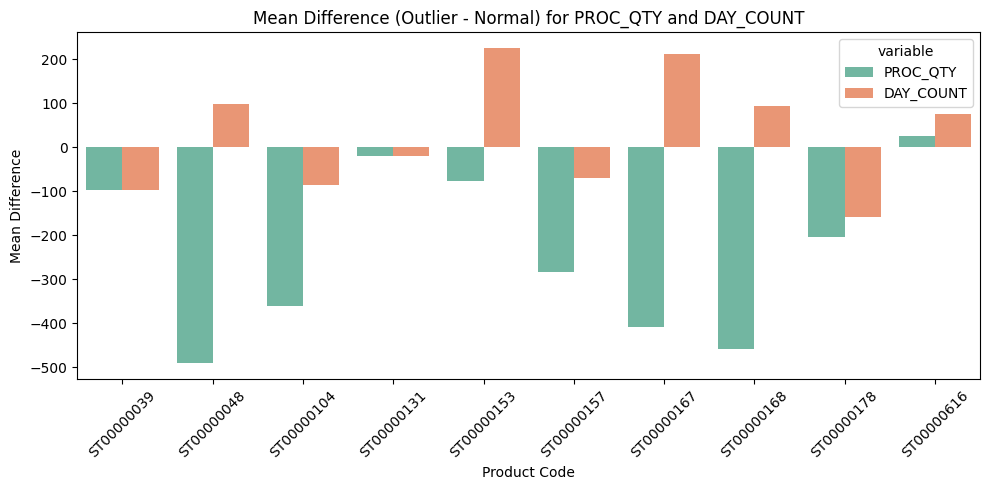

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_proc_day,
    x='stock_mst_code',
    y='diff',
    hue='variable',
    palette='Set2'
)
plt.title('Mean Difference (Outlier - Normal) for PROC_QTY and DAY_COUNT')
plt.xlabel('Product Code')
plt.ylabel('Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This bar chart shows how process quantity (PROC_QTY) and day count (DAY_COUNT) differ between normal and defective (outlier) samples for each product type (stock_mst_code).
For each product, two bars (PROC_QTY and DAY_COUNT) are shown side by side.
A positive (+) bar indicates a higher value for defective products, while a negative (–) bar indicates a lower value.


---
**Observations:**
* For most products, the bars for PROC_QTY are negative — meaning defective items were produced in smaller batches or during low-volume runs.

* A few products (e.g., ST0000153, ST0000167, ST0000616) show positive or mixed values, suggesting defects can also occur later in the production cycle.

* DAY_COUNT differences follow a similar pattern, implying that time and production stage may influence quality outcomes.


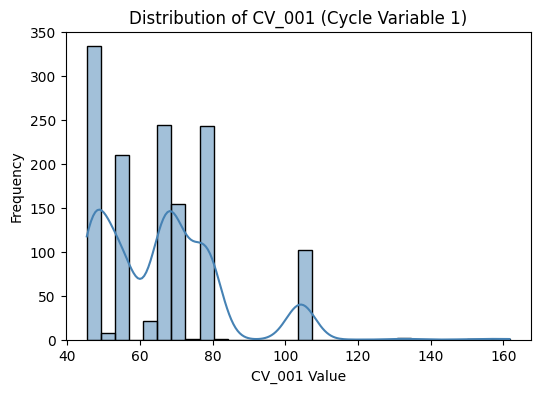

In [ ]:
#Histogram — Distribution of a Process Variable

plt.figure(figsize=(6,4))
sns.histplot(df['CV_001'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of CV_001 (Cycle Variable 1)')
plt.xlabel('CV_001 Value')
plt.ylabel('Frequency')
plt.show()


This histogram shows the distribution of the CV_001 variable, which represents one of the key cycle parameters in the injection molding process.


---
**Observations:**
* The distribution is right-skewed, meaning most cycles occur at lower CV_001 values (around 50–80), while higher values are relatively rare.

* The presence of multiple small peaks may suggest different operating conditions or mold setups used during production.

* Extreme values (above 120) could represent anomalies or unstable process cycles.


/tmp/ipython-input-3875625089.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='MOLD_CAVITY', y='weight', data=df, palette='pastel')


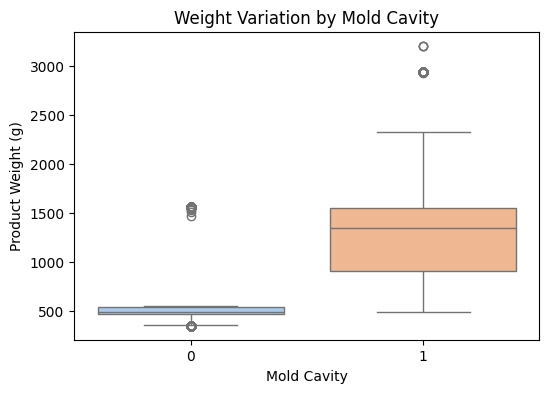

In [ ]:
#Boxplot — Compare Process Outputs Across Cavities

plt.figure(figsize=(6,4))
sns.boxplot(x='MOLD_CAVITY', y='weight', data=df, palette='pastel')
plt.title('Weight Variation by Mold Cavity')
plt.xlabel('Mold Cavity')
plt.ylabel('Product Weight (g)')
plt.show()

This boxplot compares product weight across different mold cavities used in the injection process.


---
**Observations**
* Products from Mold Cavity 1 show significantly higher and more variable weights compared to Mold Cavity 0.

* Mold Cavity 0 has a much narrower range, indicating a more stable and consistent molding process.

* Several outliers (especially in Cavity 1) suggest occasional process fluctuations or uneven pressure distribution between molds.


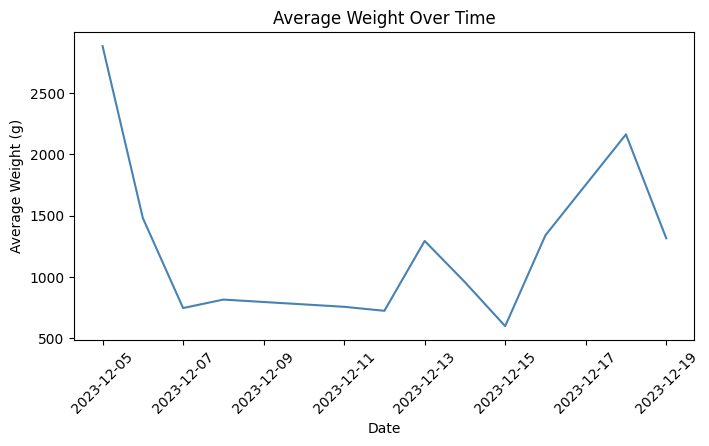

In [ ]:
#Line Graph — Average Weight by Day

df['SPC_DATETIME'] = pd.to_datetime(df['SPC_DATETIME'])
avg_weight = df.groupby(df['SPC_DATETIME'].dt.date)['weight'].mean()

plt.figure(figsize=(8,4))
plt.plot(avg_weight.index, avg_weight.values, color='steelblue')
plt.title('Average Weight Over Time')
plt.xlabel('Date')
plt.ylabel('Average Weight (g)')
plt.xticks(rotation=45)
plt.show()


This line chart shows how the average product weight changed over time during the production period.

---


**Observations**
* There are clear fluctuations in average weight across different dates, with sharp drops and peaks — indicating changes in process conditions or material flow.

* The lowest weights are observed around December 15, while early production days show unusually high values.

* This suggests possible machine setup effects, parameter drift, or batch differences influencing product consistency.

In [ ]:
daily_summary = df.groupby('DAY_COUNT').agg(
    total_cycles=('INJ_ID', 'count'),
    avg_weight=('weight', 'mean')
)

daily_summary.head()


,total_cycles,avg_weight
DAY_COUNT,,
9.0,1,1343.30
17.0,1,1338.70
21.0,1,1342.90
22.0,2,996.55
25.0,2,1340.25


This table shows the total number of injection cycles (total_cycles) and the average product weight (avg_weight) for each production day (DAY_COUNT).


---

**Observations**

* Production activity was low and irregular, with only 1–2 cycles recorded per day.

* The average product weight remains relatively stable, around 1300–1350, except for a slight dip on Day 22 (996.55), which could indicate a temporary fluctuation in process conditions or material consistency.

* Overall, despite small sample sizes, the process shows consistency in output weight across days.

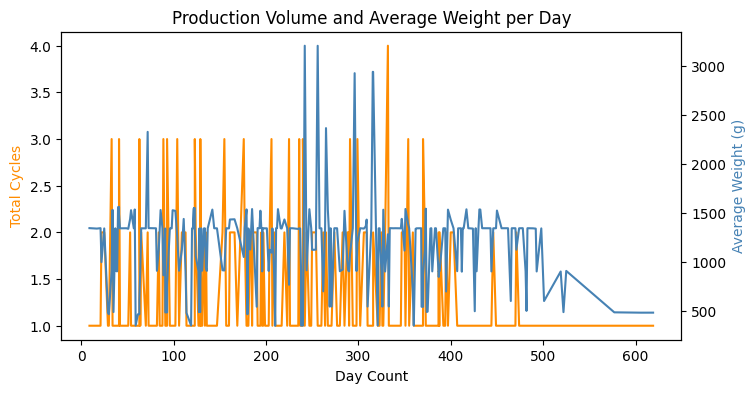

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,4))

ax1.plot(daily_summary.index, daily_summary['total_cycles'], color='darkorange', label='Total Cycles')
ax1.set_xlabel('Day Count')
ax1.set_ylabel('Total Cycles', color='darkorange')

ax2 = ax1.twinx()
ax2.plot(daily_summary.index, daily_summary['avg_weight'], color='steelblue', label='Avg Weight')
ax2.set_ylabel('Average Weight (g)', color='steelblue')

plt.title('Production Volume and Average Weight per Day')
plt.show()


This chart illustrates the relationship between production volume (Total Cycles) and average product weight over time (DAY_COUNT).


---

**Observations**
* The process shows irregular variations in both output and product weight, hinting at periodic instability in production conditions.

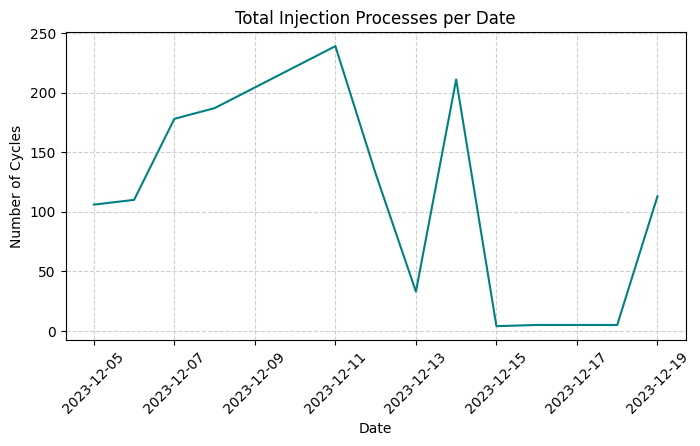

In [ ]:
# Convert timestamp to datetime
df['SPC_DATETIME'] = pd.to_datetime(df['SPC_DATETIME'])

# Count the number of cycles per date
process_per_day = df.groupby(df['SPC_DATETIME'].dt.date).size()

plt.figure(figsize=(8,4))
process_per_day.plot(kind='line', color='teal')
plt.title('Total Injection Processes per Date')
plt.xlabel('Date')
plt.ylabel('Number of Cycles')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



This line chart shows the total number of injection molding cycles performed on each recorded production date.

---
**Observations**
* The number of processes fluctuates significantly across dates, indicating uneven production activity.
* The overall pattern shows alternating high and low operation days, which may reflect batch-based scheduling or irregular production planning.


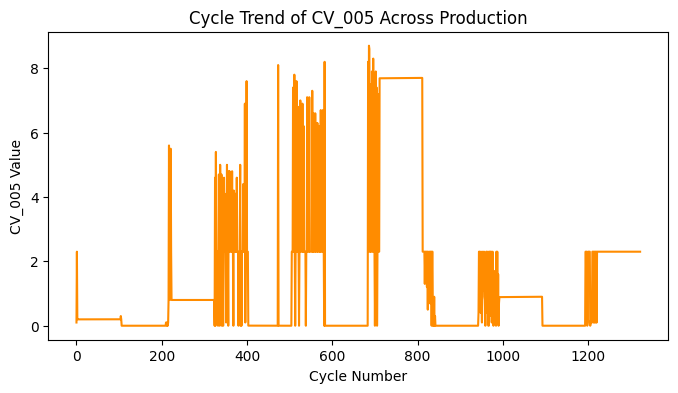

In [ ]:
#Cycle Trend — Process Stability Over Time

plt.figure(figsize=(8,4))
sns.lineplot(x=range(len(df)), y='CV_005', data=df, color='darkorange')
plt.title('Cycle Trend of CV_005 Across Production')
plt.xlabel('Cycle Number')
plt.ylabel('CV_005 Value')
plt.show()



This line chart displays the trend of CV_005 (Cycle Variable 5) across all production cycles, showing how this process parameter changes over time.


---
**Observations**
* The CV_005 values fluctuate widely throughout production, alternating between periods of stability and sharp spikes.
* Flat sections suggest periods of steady operation, while sudden drops or rises may reflect sensor resets or changes in operating conditions.


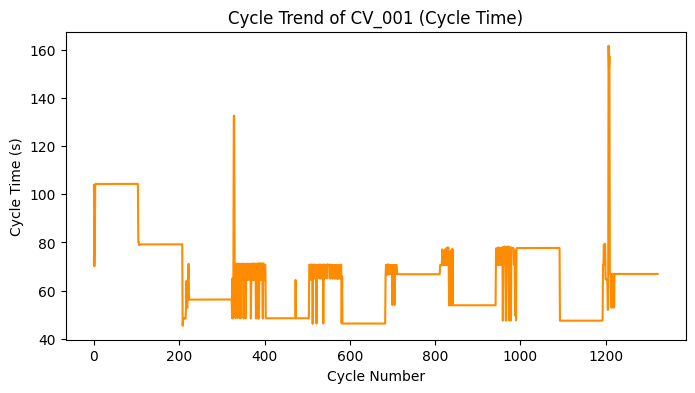

In [ ]:
plt.figure(figsize=(8,4))
sns.lineplot(x=range(len(df)), y='CV_001', data=df, color='darkorange')
plt.title('Cycle Trend of CV_001 (Cycle Time)')
plt.xlabel('Cycle Number')
plt.ylabel('Cycle Time (s)')
plt.show()

This plot illustrates how CV_001 (Cycle Time) changes across all recorded production cycles.


---
**Observations**:
* Cycle time (CV_001) is mostly stable but occasionally experiences sharp increases, which may correspond to machine adjustments, maintenance events, or changes in material flow.


**Summary: Impact analysis of Others(PROC_QTY, DAT_COUNT) categories for defect classification**

This section examined how production quantity (PROC_QTY) and day count (DAY_COUNT) relate to product quality, along with trends in process stability over time.

**Key findings:**

* Most defective products occurred during smaller or earlier production batches.

* The bar chart comparison confirmed this trend. For most product types, defective items appeared when production volumes were lower or earlier in the timeline.

* Analysis of daily and time-based trends showed fluctuations in both production volume and average product weight, implying that process stability varied over time.

* The histogram and boxplot revealed that some process parameters (e.g., CV_001, weight by mold cavity) show non-uniform distributions, indicating that differences in mold conditions or settings may influence product variation.

* Time-series graphs of CV_001 and CV_005 demonstrated periods of instability, such as spikes and dips.

**Conclusion**
While overall production remains consistent, periodic variations in process parameters and production timing correlate with defect occurrences.
Defects tend to emerge in early or unstable process phases, emphasizing the need for better calibration and continuous monitoring of both production volume and time-based variables to maintain consistent product quality.

**(Exploratory Data Analysis) Product-wise Weight Distribution Conclusion**

* The combined analysis reveals that defect generation is more strongly correlated with variations in process cycles and timing (CV group) rather than with sensor settings or environmental parameters.
In particular:

* Cycle irregularities and early production instability are key risk factors.

* Continuous parameter monitoring and early-phase process calibration are recommended to reduce outlier occurrence.

* Product-specific optimization should be prioritized, as some product codes exhibit greater sensitivity to process fluctuations.

#Section 2: Data Quality & Preparation

**In Assignment 1**, data were classified into normal and outlier groups based on the "Weight" variable using the statistical criterion of mean ±2xstandard deviation, and were labeled as normal or defective accordingly  
**In Assignment 2**, based on this labeling result, the distribution of outliers and missing values within ceac category is analyzed to assess data quality.

There were no explicit missing values(nan) in the dataset.  
Therefore, considering the characteristics of the process dataset domain, the first step was to identify variables whose values could be interpreted as MNAR (Missing Not At Random).

In [ ]:
print("total missing(nan) count:", df_labeled.isna().sum().sum())

total missing(nan) count: 0


**Count the number of unique values for each variable by Stock_mst_code to identify which variables are meaningful and which are not**  
It is assumed that a specific product may have either identical or varying values.
If a variable has diverse values, it indicates that the variable is being used for process control

In [ ]:
# select numeric feature
num_cols = df_labeled.select_dtypes(include=[np.number]).columns

# calculate the number of unique values by product code
unique_counts = df_labeled.groupby('stock_mst_code')[num_cols].nunique()

# DataFrame
unique_counts

,INJ_ID,INJ_NO,PROC_QTY,CV_001,CV_002,CV_003,CV_004,CV_005,CV_006,CV_007,...,SV_059,SV_060,SV_063,MOLD_CAVITY,weight,mean,std,count,UCL,LCL
stock_mst_code,,,,,,,,,,,,,,,,,,,,,
ST00000039,103,1,103,103,103,1,1,2,103,2,...,1,1,1,1,103,1,1,1,1,1
ST00000048,136,1,136,117,118,105,110,114,123,105,...,1,1,1,1,134,1,1,1,1,1
ST00000104,107,1,107,102,106,2,1,2,103,102,...,1,1,2,1,106,1,1,1,1,1
ST00000131,101,1,101,101,101,1,101,101,101,101,...,1,1,1,1,101,1,1,1,1,1
ST00000153,104,1,104,103,103,1,1,3,103,103,...,1,1,1,1,104,1,1,1,1,1
ST00000157,106,1,106,3,106,2,1,1,3,102,...,1,1,1,1,103,1,1,1,1,1
ST00000167,121,1,121,104,112,1,1,101,4,107,...,1,1,2,1,120,1,1,1,1,1
ST00000168,104,1,104,102,103,1,1,1,102,102,...,1,1,1,1,104,1,1,1,1,1
ST00000178,150,1,150,17,25,6,9,131,126,107,...,1,1,2,1,144,1,1,1,1,1


In [ ]:
low_variability_vars = unique_counts.columns[(unique_counts <= 1).all()]
low_variability_vars

Index(['INJ_NO', 'SV_002', 'SV_003', 'SV_004', 'SV_005', 'SV_011', 'SV_012',
       'SV_013', 'SV_015', 'SV_016', 'SV_017', 'SV_018', 'SV_019', 'SV_020',
       'SV_021', 'SV_022', 'SV_024', 'SV_028', 'SV_031', 'SV_032', 'SV_033',
       'SV_034', 'SV_037', 'SV_038', 'SV_039', 'SV_042', 'SV_043', 'SV_044',
       'SV_045', 'SV_046', 'SV_049', 'SV_050', 'SV_057', 'SV_058', 'SV_059',
       'SV_060', 'MOLD_CAVITY', 'mean', 'std', 'count', 'UCL', 'LCL'],
      dtype='object')

For the  SV_variables, those with only one unique value appear to be either unused or fixed,since they have the same value across all products  

We checked the number of unique values of the variables to be removed to confirm they were constant across products.  
('mean', 'std', 'count', 'UCL', and 'LCL' are variables created for statistical calculations and are therefore excluded)

In [ ]:
low_cols = [
    'INJ_NO', 'SV_002', 'SV_003', 'SV_004', 'SV_005', 'SV_011', 'SV_012',
    'SV_013', 'SV_015', 'SV_016', 'SV_017', 'SV_018', 'SV_019', 'SV_020',
    'SV_021', 'SV_022', 'SV_024', 'SV_028', 'SV_031', 'SV_032', 'SV_033',
    'SV_034', 'SV_037', 'SV_038', 'SV_039', 'SV_042', 'SV_043', 'SV_044',
    'SV_045', 'SV_046', 'SV_049', 'SV_050', 'SV_057', 'SV_058', 'SV_059',
    'SV_060', 'MOLD_CAVITY'
]

The distributions of these variables were examined in detail using tables and bar plots.  
Many variables were found to be concentrated around specific values or limited to a small range of distinct values.  
In particular, the value 0 in many variables may indicate that the corresponding function is inactive or unused.
Although these variables do not contain explicit missing values, they can be regarded as structural missing values — data that do not exist due to the process configuration — and thus correspond to the **MNAR (Missing Not At Random)** type.   

Therefore, since such variables are more likely to introduce noise than improve predictive performance, they were removed from the dataset.

In [ ]:
unique_values_dict={}

for col in low_cols:
    uniques = df_labeled[col].unique()
    uniques_sorted = sorted(uniques)
    unique_values_dict[col] = uniques_sorted

unique_values_df = pd.Series(unique_values_dict,name = 'unique values').to_frame()
unique_values_df.index.name = 'variable name'
unique_values_df = unique_values_df.reset_index()
unique_values_df

,variable name,unique values
0,INJ_NO,[12]
1,SV_002,"[165, 190, 195, 200, 205, 210]"
2,SV_003,"[155, 170, 180, 185, 190, 195, 205]"
3,SV_004,"[153, 160, 165, 170, 180, 185, 190]"
4,SV_005,"[0, 150, 160, 165]"
5,SV_011,"[0, 20, 25, 30, 35]"
6,SV_012,"[0, 8, 19]"
7,SV_013,"[75, 80, 85, 90, 100, 104, 118, 120, 125, 140]"
8,SV_015,"[0, 50, 60, 62, 70, 75, 80, 90]"
9,SV_016,"[0, 40, 70, 80, 93]"


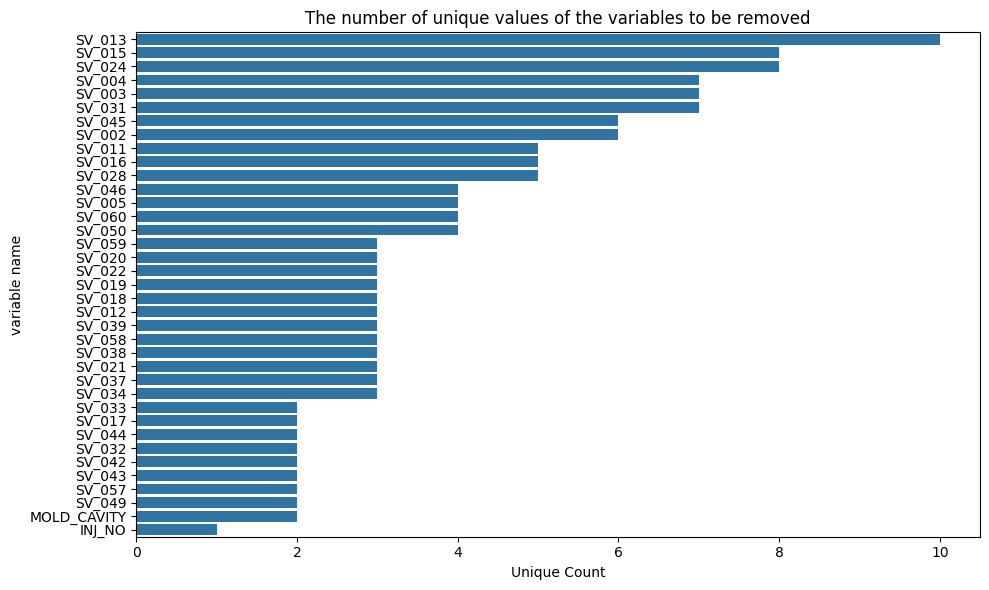

In [ ]:
df_unique = unique_values_df.copy()
df_unique['Unique Count'] = df_unique['unique values'].apply(len)

plt.figure(figsize=(10, 6))
sns.barplot(x='Unique Count', y='variable name', data=df_unique.sort_values('Unique Count', ascending=False))
plt.title('The number of unique values of the variables to be removed')
plt.tight_layout()
plt.show()

In [ ]:
#Remove simple configuration values or MNAR variables
df_cleaned = df_labeled.drop(columns=low_variability_vars)

After removing some SV variables, outliers were identified in the remaining SV data using   
the same condition (mean ± 2σ) that was applied for labeling with the Weight variable.

In [ ]:
# Select numeric columns only
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns

# Calculate per-item mean and standard deviation, then count outliers for each variable
stats = df_cleaned.groupby('stock_mst_code')[num_cols].agg(['mean','std']).reset_index()
flat_stats = stats.set_index('stock_mst_code')
threshold = 2

missing_like_summary = {}

for col in num_cols:
    mean_col = flat_stats[(col, 'mean')]
    std_col = flat_stats[(col, 'std')]
    for code in df_cleaned['stock_mst_code'].unique():
        code_mask = df_cleaned['stock_mst_code'] == code
        mean, std = mean_col[code], std_col[code]
        lower, upper = mean - threshold * std, mean + threshold * std

        # Treat value <= 0 or beyound ± 2σ as outliers
        mask = (df_cleaned.loc[code_mask, col] <= 0) | (df_cleaned.loc[code_mask, col] < lower) | (df_cleaned.loc[code_mask, col] > upper)
        missing_like_summary[(code, col)] = mask.sum()

missing_df = pd.Series(missing_like_summary).unstack().fillna(0).astype(int)
missing_df = missing_df.reset_index(names='stock_mst_code')

In [ ]:
sv_only = missing_df[['stock_mst_code'] + [col for col in missing_df.columns if 'SV' in col]]
sv_only

,stock_mst_code,SV_001,SV_008,SV_009,SV_010,SV_014,SV_023,SV_025,SV_040,SV_041,SV_051,SV_055,SV_056,SV_063
0,ST00000039,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ST00000048,0,0,0,137,0,137,137,0,0,0,0,0,0
2,ST00000104,0,0,0,0,0,0,0,6,7,0,0,0,1
3,ST00000131,0,0,0,0,0,0,0,0,0,1,0,0,0
4,ST00000153,0,0,0,0,0,0,0,0,3,0,0,0,0
5,ST00000157,0,0,0,0,0,0,0,107,0,0,107,0,0
6,ST00000167,0,0,0,0,0,0,0,0,0,18,122,0,1
7,ST00000168,0,0,0,105,0,0,105,0,0,0,105,0,0
8,ST00000178,0,0,0,151,0,151,151,0,0,0,0,0,0
9,ST00000616,14,1,1,0,0,1,43,0,0,1,0,1,5


Outliers are observed in all products except for ST00000039

In [ ]:
sv_cols = [col for col in missing_df.columns if col.startswith('SV_')]

sv_numeric = missing_df[['stock_mst_code'] + sv_cols].copy()
sv_numeric[sv_cols] = sv_numeric[sv_cols].apply(pd.to_numeric, errors='coerce')

sv_variable_variation = sv_numeric.apply(
    lambda row: row[sv_cols][row[sv_cols] >= 1].index.tolist(), axis=1
)

sv_variable_variation = pd.DataFrame({
    'stock_mst_code': sv_numeric['stock_mst_code'],
    'sv_columns_with_multiple_values': sv_variable_variation
})

print()
sv_variable_variation

,stock_mst_code,sv_columns_with_multiple_values
0,ST00000039,[]
1,ST00000048,"[SV_010, SV_023, SV_025]"
2,ST00000104,"[SV_040, SV_041, SV_063]"
3,ST00000131,[SV_051]
4,ST00000153,[SV_041]
5,ST00000157,"[SV_040, SV_055]"
6,ST00000167,"[SV_051, SV_055, SV_063]"
7,ST00000168,"[SV_010, SV_025, SV_055]"
8,ST00000178,"[SV_010, SV_023, SV_025]"
9,ST00000616,"[SV_001, SV_008, SV_009, SV_023, SV_025, SV_05..."


For the same product, the point in time (SPC_DATETIME) when the SV variable setting changed was identified, and the period was divided into before and after segments to calculate defect rates.  
A table was created showing the product name, variable name, change time, defect rates before and after the change, and their difference.

In [ ]:
def calculate_defect_rate(df):
    if df.empty:
        return np.nan
    return (df['label'] == 'outlier').mean()

result_list = []

for idx, row in sv_variable_variation.iterrows():
    code = row['stock_mst_code']
    sv_list = row['sv_columns_with_multiple_values']

    df_sub = df_cleaned[df_cleaned['stock_mst_code'] == code].sort_values('SPC_DATETIME')

    for sv in sv_list:
        change_points = df_sub[sv].ne(df_sub[sv].shift()).cumsum()
        most_common = df_sub.groupby(change_points)[sv].agg(['first', 'count']).reset_index()

        if len(most_common) < 2:
            continue

        first_change_idx = df_sub[sv].ne(df_sub[sv].iloc[0]).idxmax()
        change_time = df_sub.loc[first_change_idx, 'SPC_DATETIME']

        before = df_sub[df_sub['SPC_DATETIME'] < change_time]
        after = df_sub[df_sub['SPC_DATETIME'] >= change_time]

        before_rate = calculate_defect_rate(before)
        after_rate = calculate_defect_rate(after)

        result_list.append({
            'stock_mst_code': code,
            'variable': sv,
            'change_time': change_time,
            'before_defect_rate': before_rate,
            'after_defect_rate': after_rate,
            'change': f"{after_rate - before_rate:+.2%}" if pd.notna(before_rate) and pd.notna(after_rate) else "N/A"
        })

df_defect_summary = pd.DataFrame(result_list)

In [ ]:
df_defect_summary

,stock_mst_code,variable,change_time,before_defect_rate,after_defect_rate,change
0,ST00000104,SV_040,2023-12-14 10:04,0.400000,0.019417,-38.06%
1,ST00000104,SV_041,2023-12-14 10:04,0.400000,0.019417,-38.06%
2,ST00000104,SV_063,2023-12-14 8:57,0.028037,1.000000,+97.20%
3,ST00000131,SV_051,2023-12-05 17:22,1.000000,0.000000,-100.00%
4,ST00000153,SV_041,2023-12-06 8:46,0.666667,0.009804,-65.69%
5,ST00000167,SV_051,2023-12-07 10:22,0.750000,0.008772,-74.12%
6,ST00000167,SV_063,2023-12-06 14:02,1.000000,0.049587,-95.04%
7,ST00000616,SV_001,2023-12-08 11:05,0.021277,0.022624,+0.13%
8,ST00000616,SV_008,2023-12-07 10:34,1.000000,0.018727,-98.13%
9,ST00000616,SV_009,2023-12-07 10:34,1.000000,0.018727,-98.13%


Since the variables *SV_001* and *SV_025* had little impact, it is considered that removing them would not significantly affect the model performance.
The other SV variables will be re-evaluated together with the CV variables to check their feature importance in future analysis.



---



In [ ]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, RobustScaler

In [ ]:
file_id = "1ZnJPuFORtOpEIsiUUOzPMvjTBwjGD7Wk"  # paste your file’s real ID here
url = f"https://drive.google.com/uc?export=download&id={file_id}"

injection_df = pd.read_csv(url)
injection_df.head()

,INJ_ID,INJ_NO,SPC_DATETIME,PROC_QTY,CV_001,CV_002,CV_003,CV_004,CV_005,CV_006,...,SV_055,SV_056,SV_057,SV_058,SV_059,SV_060,SV_063,MOLD_CAVITY,stock_mst_code,weight
0,2678317.000,12,2023-12-05 16:17,871.000000,103.800000,511.400000,24.0,0.200000,0.100000,61.600000,...,6,6,35,30,35,50,65,1,ST00000131,2923.200000
1,2678337.000,12,2023-12-05 16:19,1644.000000,70.100000,259.000000,13.6,0.000000,2.300000,30.200000,...,1,1,0,0,0,50,46,1,ST00000616,1328.700000
2,2678493.000,12,2023-12-05 16:36,353.000000,80.600000,451.100000,15.0,0.000000,0.200000,45.800000,...,4,6,0,50,140,100,50,0,ST00000153,1462.600000
3,2678974.285,12,2023-12-05 17:22,890.504008,104.287600,510.912400,24.0,0.102480,0.197520,60.527280,...,6,6,35,30,35,50,65,1,ST00000131,2936.657766
4,2678974.454,12,2023-12-05 17:22,890.509018,104.287725,510.912275,24.0,0.102455,0.197545,60.527004,...,6,6,35,30,35,50,65,1,ST00000131,2936.661222


## **Numerical Transformations**

We chose the following features to check and explore as they represent the most critical physical and process parameters in injection molding - time, pressure, temperature, and resistance.

Together, they provide a comprehensive view of the machine’s operational stability and product quality performance.


* Cycle Time (CV_001) – Represents the total duration of one injection molding cycle, combining injection, cooling, and ejection stages. It reflects the overall efficiency of the process and is fundamental for productivity and consistency analysis.

* Injection Pressure (CV_002) – Captures the actual pressure applied during the injection phase. This variable is crucial for understanding material flow behavior and detecting potential quality issues such as short shots or flash.

* Back Pressure (CV_005) – Indicates the resistance encountered by the screw during plasticizing. It directly affects melt temperature, material homogeneity, and final product quality, making it an important stability parameter.

* Mold Temperature (Zone 2) (CV_014) – Represents the cooling temperature at a mid-region of the mold cavity. This zone provides a stable measure of thermal control, influencing cycle time, part cooling rate, and dimensional accuracy.






In [ ]:
# Standardization
scaler_std = StandardScaler()
injection_df['CV001_std'] = scaler_std.fit_transform(injection_df[['CV_001']])

# Log Transform (avoid zeros or negatives)
injection_df['CV002_log'] = np.log1p(injection_df['CV_002'])

# Min–Max Scaling
scaler_mm = MinMaxScaler()
injection_df['CV005_minmax'] = scaler_mm.fit_transform(injection_df[['CV_005']])

# Power (Box-Cox / Yeo-Johnson)
pt = PowerTransformer(method='yeo-johnson')  # handles zeros/negatives
injection_df['CV014_power'] = pt.fit_transform(injection_df[['CV_014']])

**Standardizing Cycle Times (CV_001)**

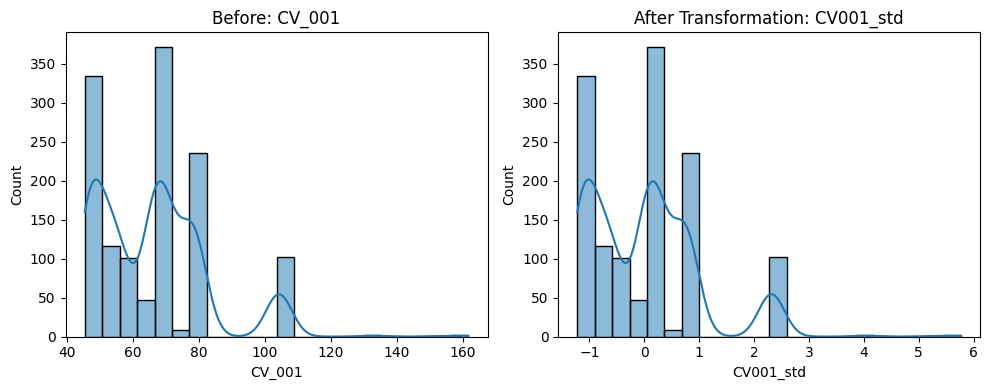

Insight:
The CV_001 - Cycle Time variable was slstandardized to center its mean around 0 and scale its variance.
However it remains slighltly right-skewed after standardization, indicating the transformation only the center and spread, not the distribution shape.
This stil makes the feature comparable with others using different units, which is essential for the next steps in Data Analysis.


In [ ]:
#Standardization of CV001

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(injection_df['CV_001'], kde=True)
plt.title('Before: CV_001')
plt.subplot(1,2,2)
sns.histplot(injection_df['CV001_std'], kde=True)
plt.title('After Transformation: CV001_std')
plt.tight_layout()
plt.show()

#Insight
print("Insight:")
print("The CV_001 - Cycle Time variable was slstandardized to center its mean around 0 and scale its variance.")
print("However it remains slighltly right-skewed after standardization, indicating the transformation only the center and spread, not the distribution shape.")
print("This stil makes the feature comparable with others using different units, which is essential for the next steps in Data Analysis.")

**Applying Log Transformation on Pressure Values at Injection Phase (CV_002) that led to the reviewing Pressure Values at Holding Phase Phase (CV_003)**




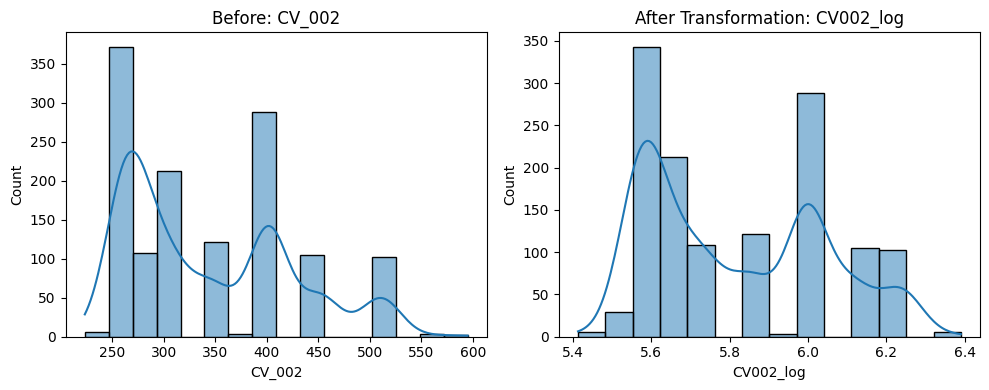

Insight:
The log transformation was to CV_002 applied to reduce right skewness and compress extreme values, stabilizing variance and making the data distribution more symmetric.
This improves model interpretability and aligns with the Power Transformation concept.
This transformation also stabilizes variance, making the variable less sensitive to rare high-pressure cycles.


In [ ]:
#Log Transformation of CV002

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(injection_df['CV_002'], kde=True)
plt.title('Before: CV_002')
plt.subplot(1,2,2)
sns.histplot(injection_df['CV002_log'], kde=True)
plt.title('After Transformation: CV002_log')
plt.tight_layout()
plt.show()

#Insight
print("Insight:")
print("The log transformation was to CV_002 applied to reduce right skewness and compress extreme values, stabilizing variance and making the data distribution more symmetric.")
print("This improves model interpretability and aligns with the Power Transformation concept.")
print("This transformation also stabilizes variance, making the variable less sensitive to rare high-pressure cycles.")

Skewness: 1.0709869119429793


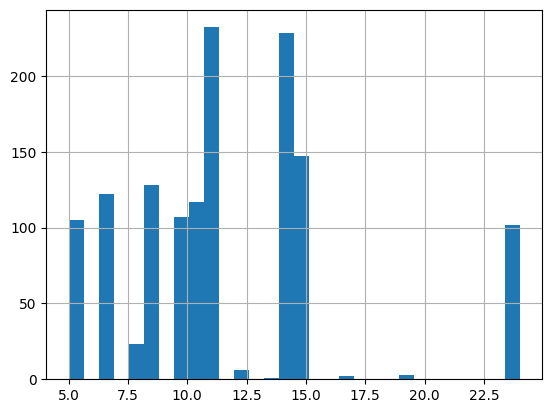

In [ ]:
#Given that CV_002 and CV_003 goes together, we will now check for the quality of CV_003

injection_df['CV_003'].hist(bins=30)
print("Skewness:", injection_df['CV_003'].skew())

In [ ]:
injection_df['CV003_log'] = np.log1p(injection_df['CV_003'])

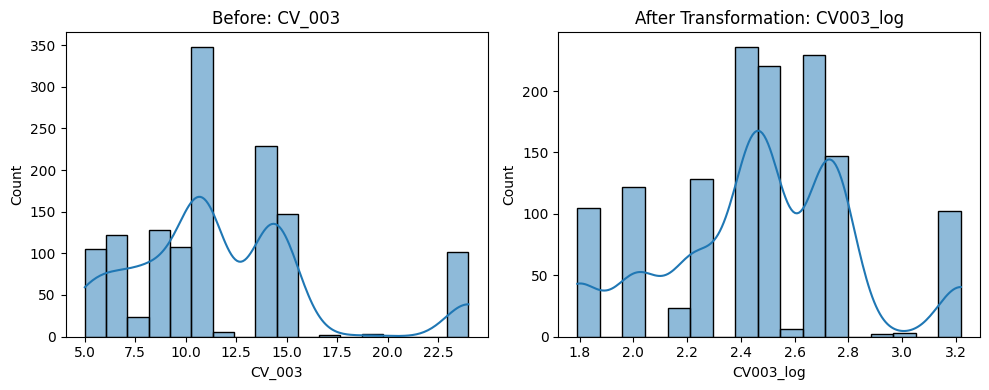

Insight:
Since it represents a secondary pressure phase similar to CV_002, a log transformation was applied.
Like in CV_002, The transformation in CV_003 reduced skewness and compressed large values, aligning both pressure variables on comparable, more symmetric scales.
We consider this similarity between the two variables as valuable because it help us understand the relationship between injection and holding pressures.


In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(injection_df['CV_003'], kde=True)
plt.title('Before: CV_003')
plt.subplot(1,2,2)
sns.histplot(injection_df['CV003_log'], kde=True)
plt.title('After Transformation: CV003_log')
plt.tight_layout()
plt.show()

#Insight
print("Insight:")
print("Since it represents a secondary pressure phase similar to CV_002, a log transformation was applied.")
print("Like in CV_002, The transformation in CV_003 reduced skewness and compressed large values, aligning both pressure variables on comparable, more symmetric scales.")
print("We consider this similarity between the two variables as valuable because it help us understand the relationship between injection and holding pressures.")


**Changing the Scaling Method for Back Pressure (CV_005)**

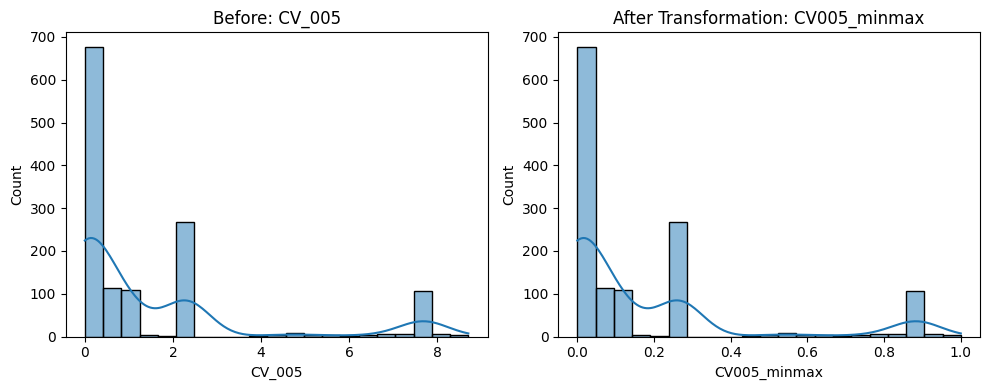

Insight:
Initially we wanted to implement a Min Max Scaler for CV_005 but based on the current result, the majority of the data is crowded near 0–2, but a few values stretch as far as 8+, forming a long right tail.
Meaning there would be outliers, so we are changing from From MinMax Scalling to Robust Scaling


In [ ]:
#MinMax Scaling of CV005

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(injection_df['CV_005'], kde=True)
plt.title('Before: CV_005')
plt.subplot(1,2,2)
sns.histplot(injection_df['CV005_minmax'], kde=True)
plt.title('After Transformation: CV005_minmax')
plt.tight_layout()
plt.show()


#Insight
print("Insight:")
print("Initially we wanted to implement a Min Max Scaler for CV_005 but based on the current result, the majority of the data is crowded near 0–2, but a few values stretch as far as 8+, forming a long right tail.")
print("Meaning there would be outliers, so we are changing from From MinMax Scalling to Robust Scaling")

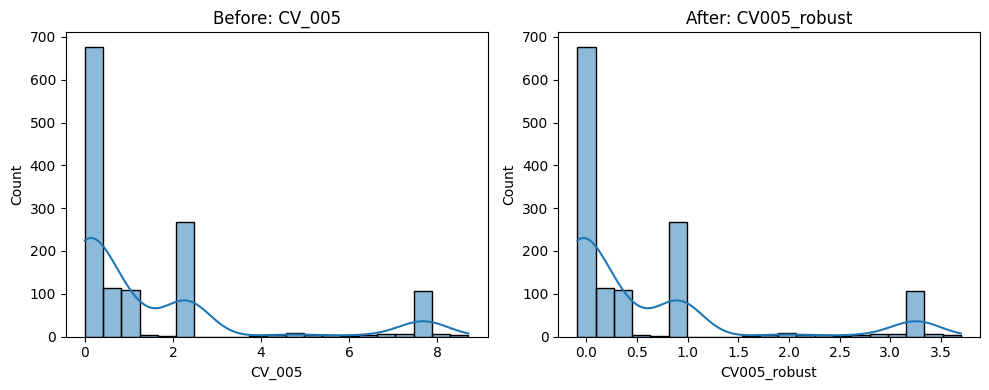

Insight:
Since the CV_005 - Back Pressure variable contained several high outliers that compressed the data when Min–Max scaling was applied,
Using a Robust Scaling method produced a better distribution as it centers around the median and scaling based on the interquartile range.
This preserves the structure of typical pressure values while minimizing the influence of rare extremes.


In [ ]:
rs = RobustScaler()
injection_df['CV005_robust'] = rs.fit_transform(injection_df[['CV_005']])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(injection_df['CV_005'], kde=True)
plt.title('Before: CV_005')
plt.subplot(1,2,2)
sns.histplot(injection_df['CV005_robust'], kde=True)
plt.title('After: CV005_robust')
plt.tight_layout()
plt.show()


#Insight
print("Insight:")
print("Since the CV_005 - Back Pressure variable contained several high outliers that compressed the data when Min–Max scaling was applied,")
print("Using a Robust Scaling method produced a better distribution as it centers around the median and scaling based on the interquartile range.")
print("This preserves the structure of typical pressure values while minimizing the influence of rare extremes.")



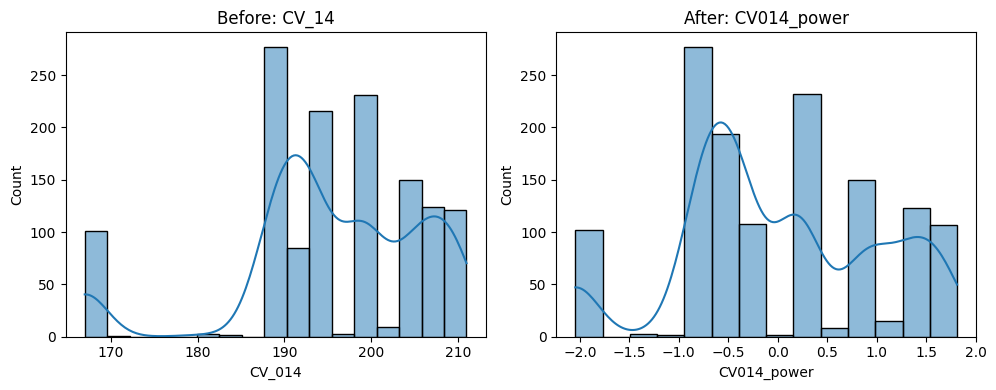

Insight:
The CV_014 feature, representing mold temperature, exhibited a mild right skew prior to the transformation.
Applying the Yeo–Johnson power transformation reduced skewness, stabilized variance, and centered the distribution around zero.
This makes the feature more suitable for using it in Linear Models and Neural Networks


In [ ]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(injection_df['CV_014'], kde=True)
plt.title('Before: CV_14')
plt.subplot(1,2,2)
sns.histplot(injection_df['CV014_power'], kde=True)
plt.title('After: CV014_power')
plt.tight_layout()
plt.show()

#Insight
print("Insight:")
print("The CV_014 feature, representing mold temperature, exhibited a mild right skew prior to the transformation.")
print("Applying the Yeo–Johnson power transformation reduced skewness, stabilized variance, and centered the distribution around zero.")
print("This makes the feature more suitable for using it in Linear Models and Neural Networks")




Current Injection Dataset

In [ ]:
injection_df

,INJ_ID,INJ_NO,SPC_DATETIME,PROC_QTY,CV_001,CV_002,CV_003,CV_004,CV_005,CV_006,...,MachineID_encoded,MOLD_CAVITY_encoded,stock_mst_code_encoded,PressureLevel,PressureLevel_injection,PressureLevel_holding,CV001_std,CV002_log,CV005_minmax,CV014_power
0,2678317.000,12,2023-12-05 16:17:00,871.000000,103.800000,511.400000,24.0,0.200000,0.100000,61.600000,...,0,1,0.077098,High,High,High,2.289438,6.239106,0.011494,-1.879806
1,2678337.000,12,2023-12-05 16:19:00,1644.000000,70.100000,259.000000,13.6,0.000000,2.300000,30.200000,...,0,1,0.202570,Low,Low,Normal,0.264319,5.560682,0.264368,-0.768549
2,2678493.000,12,2023-12-05 16:36:00,353.000000,80.600000,451.100000,15.0,0.000000,0.200000,45.800000,...,0,0,0.079365,High,High,High,0.895291,6.113903,0.022989,-0.126082
3,2678974.285,12,2023-12-05 17:22:00,890.504008,104.287600,510.912400,24.0,0.102480,0.197520,60.527280,...,0,1,0.077098,High,High,High,2.318739,6.238154,0.022703,-2.042367
4,2678974.454,12,2023-12-05 17:22:00,890.509018,104.287725,510.912275,24.0,0.102455,0.197545,60.527004,...,0,1,0.077098,High,High,High,2.318747,6.238153,0.022706,-2.042406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1318,2765856.300,12,2023-12-19 12:29:00,1180.963280,66.900000,259.597797,14.1,0.000000,2.300000,31.099266,...,0,1,0.202570,Low,Low,High,0.072023,5.562978,0.264368,-0.418682
1319,2765856.534,12,2023-12-19 12:29:00,1180.975520,66.900000,259.598531,14.1,0.000000,2.300000,31.099510,...,0,1,0.202570,Low,Low,High,0.072023,5.562981,0.264368,-0.418739
1320,2765856.767,12,2023-12-19 12:29:00,1180.987760,66.900000,259.599266,14.1,0.000000,2.300000,31.099755,...,0,1,0.202570,Low,Low,High,0.072023,5.562984,0.264368,-0.418796
1321,2765857.000,12,2023-12-19 12:29:00,1181.000000,66.900000,259.600000,14.1,0.000000,2.300000,31.100000,...,0,1,0.202570,Low,Low,High,0.072023,5.562987,0.264368,-0.418853


## **Categorical Encodings**

We wanted to explore different fields that can be put into categories. Hence we have come up with the following:

* SPC_DATETIME - We wanted to see how diverse the data by introducing a time based category called Shift, derived from SPC_DATETIME. It is ordinally encoded (Morning < Afternoon < Night) to capture time-of-day effects in a compact, ordered form.
* CV_002 and CV_003 - Since these fields are pressure points, we wanted to categorize based on its quantiles into Low, Medium and High. This has been done using One-Hot Coding
* STOCK_MST_CODE - stock_mst_code was frequency-encoded to handle cardinality  while retaining information on code prevalence. We wanted to check how frequency can be leveraged in this Dataset
* Machine ID - was label-encoded to see if we can categorize according to the machines used in the dataset
* MOLD_CAVITY - MOLD_CAVITY was label-encoded as a small discrete setting influencing output per shot.


**Ordinal Encoding for generating the shift based on the Cycle Time**
* We decided to have Morning, Afternoon and Evening as majority of the factories follows this kind of format

In [ ]:
def get_shift(hour):
  if 6 <=hour <14:
    return 'Morning'
  elif 14 <=hour <22:
    return 'Afternoon'
  else:
    return 'Night'

injection_df['SPC_DATETIME'] = pd.to_datetime(injection_df["SPC_DATETIME"], errors='coerce')
injection_df["Shift"] = injection_df['SPC_DATETIME'].dt.hour.apply(get_shift)

encoder = OrdinalEncoder(categories=[['Morning', 'Afternoon', 'Night']])
injection_df['Shift_encoded'] = encoder.fit_transform(injection_df[['Shift']])

#One-hot Encoding on Pressure Levels (During Injection Phase - CV_002 and Holding Phase - CV_003 )
def categorize_pressure(p):
    if p < q1: return 'Low'
    elif p < q2: return 'Normal'
    else: return 'High'

In [ ]:
print(injection_df[['Shift', 'Shift_encoded']].head())

       Shift  Shift_encoded
0  Afternoon            1.0
1  Afternoon            1.0
2  Afternoon            1.0
3  Afternoon            1.0
4  Afternoon            1.0


In [ ]:
#Checking the Distribution of the Shift Field
print(injection_df['Shift'].value_counts())

Shift
Morning      883
Afternoon    440
Name: count, dtype: int64


Insight: Based on the simple print function, the Dataset only comprises of Morning and Afternoon Shifts. Indicating that there are no overnight/night manufacturing work conducted. Also it is also noted that around 60% of the dataset occured during the morning while the remaining occured on the afternoon shift.

/tmp/ipython-input-1066371325.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=injection_df, x='Shift', order=['Morning','Afternoon','Night'], palette='crest')


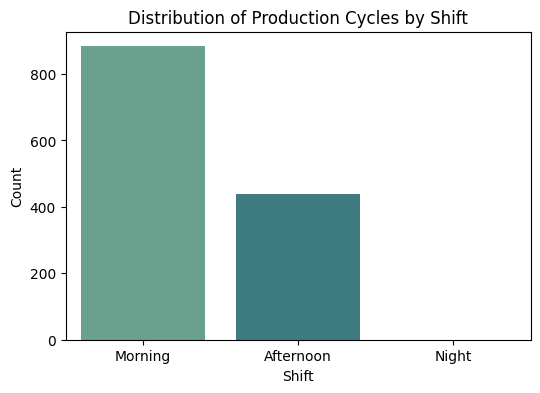

Insight:
The majority of cycles occurred during the Morning shift, followed by Afternoon. No evening production cycles
This shows that production volume is not evenly distributed across shifts(for this dataset), which may influence cycle performance and load


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=injection_df, x='Shift', order=['Morning','Afternoon','Night'], palette='crest')
plt.title('Distribution of Production Cycles by Shift')
plt.xlabel('Shift')
plt.ylabel('Count')
plt.show()

print("Insight:")
print("The majority of cycles occurred during the Morning shift, followed by Afternoon. No evening production cycles")
print("This shows that production volume is not evenly distributed across shifts(for this dataset), which may influence cycle performance and load")

**Generating the Pressure Levels Category**

In [ ]:
q1, q2 = injection_df['CV_002'].quantile([0.33, 0.66])
injection_df['PressureLevel_injection'] = injection_df['CV_002'].apply(categorize_pressure)

q1, q2 = injection_df['CV_003'].quantile([0.33, 0.66])
injection_df['PressureLevel_holding'] = injection_df['CV_003'].apply(categorize_pressure)


In [ ]:
#Distribution of the Pressure Level at Injection Stage
print(injection_df['PressureLevel_injection'].value_counts())

PressureLevel_injection
High      469
Low       437
Normal    417
Name: count, dtype: int64


In [ ]:
#Distribution of the Pressure Level at Holding Stage
print(injection_df['PressureLevel_holding'].value_counts())

PressureLevel_holding
High      479
Normal    466
Low       378
Name: count, dtype: int64


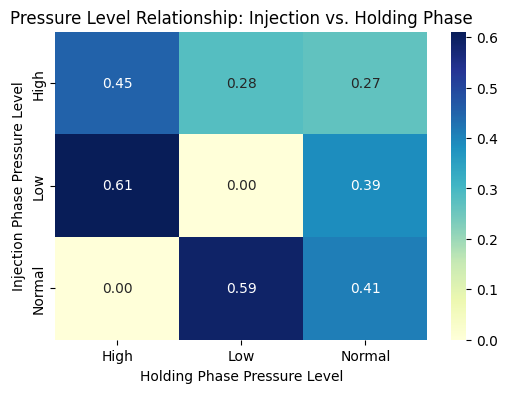

Insight:
The distribution of the Pressure Levels between the Injection and Holding stage are relatively the same.
High Pressure is the highest bucket, followed by the medium and then low buckets.


In [ ]:
cross_tab = pd.crosstab(
    injection_df['PressureLevel_injection'],
    injection_df['PressureLevel_holding'],
    normalize='index'
)

plt.figure(figsize=(6,4))
sns.heatmap(cross_tab, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Pressure Level Relationship: Injection vs. Holding Phase')
plt.xlabel('Holding Phase Pressure Level')
plt.ylabel('Injection Phase Pressure Level')
plt.show()

print("Insight:")
print("We wanted to check the relationship of the pressure levels between Injection and Holding phases.")
print("The heatmap shows that holding pressure levels adjust in response to injection pressure")
print("Low injection pressures are often followed by high holding pressures, while normal injections lead to lower or balanced holding levels")

**Frequency Encoding for Stock Code**

In [ ]:
#Frequency encoding for Stock Code
freq_map = injection_df['stock_mst_code'].value_counts(normalize=True)
injection_df['stock_mst_code_encoded'] = injection_df['stock_mst_code'].map(freq_map)

In [ ]:
#Distribution of Stock Code Encoding
print(injection_df['stock_mst_code_encoded'].value_counts())

stock_mst_code_encoded
0.202570    268
0.079365    210
0.114135    151
0.103553    137
0.092215    122
0.081633    108
0.080877    107
0.078609    104
0.077098    102
0.002268      6
0.004535      6
0.001512      2
Name: count, dtype: int64


/tmp/ipython-input-3822484632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


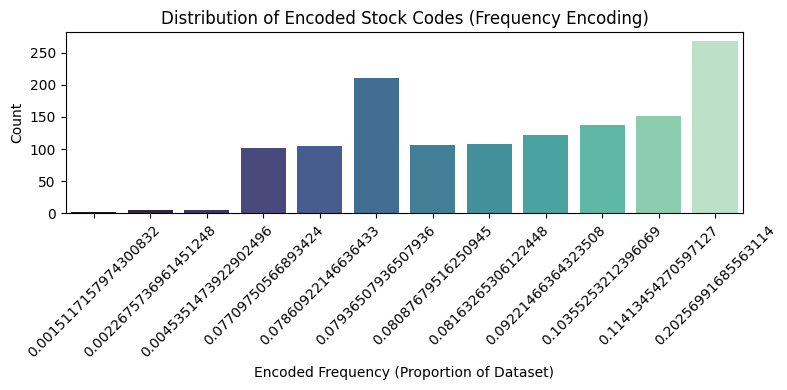

Insight:
The results show that a few products dominate production while several others occur infrequently.


In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(
    x=injection_df['stock_mst_code_encoded'].value_counts().index,
    y=injection_df['stock_mst_code_encoded'].value_counts().values,
    palette='mako'
)
plt.title('Distribution of Encoded Stock Codes (Frequency Encoding)')
plt.xlabel('Encoded Frequency (Proportion of Dataset)')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Insight:")
print("The results show that a few products dominate production while several others occur infrequently.")

**Label Encoding - From using Machine ID to Mold Cavity**

In [ ]:
#Label Encoding for Machine ID
le = LabelEncoder()
injection_df['MachineID_encoded'] = le.fit_transform(injection_df['INJ_NO'])

print(injection_df['MachineID_encoded'].value_counts())

MachineID_encoded
0    1323
Name: count, dtype: int64


Insight: The results show that only one machine is/was used in the dataset indicating that it may not be the right field for this kind of Label Encoding. Thus, applying the encoding to another feature.

In [ ]:
#Label Encoding for Mold Activity
le = LabelEncoder()
injection_df['MOLD_CAVITY_encoded'] = le.fit_transform(injection_df['MOLD_CAVITY'])

In [ ]:
#Checking the Mold Cavity Encodings

injection_df["MOLD_CAVITY_encoded"]

print(injection_df['MOLD_CAVITY_encoded'].value_counts())

MOLD_CAVITY_encoded
1    773
0    550
Name: count, dtype: int64


Insights: The dataset shows two main cavity configurations — with around 60% using one type of mold setup and 40% using the other.
This indicates that mold configurations are used relatively frequently.

###Visualizations for the different Encodings

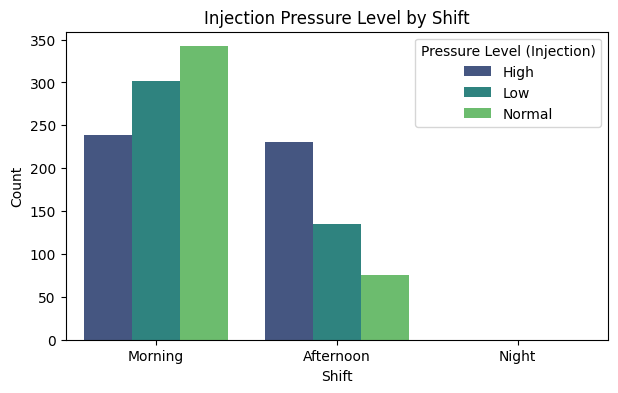

Insights:
The value counts vary per differently per shift. For morning shift, Normal Pressure were recorded the highest, and followed by low and high pressures
For afternoon shift, High Pressure were recorded the highest, and followed by low and normal pressures


In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=injection_df, x='Shift', hue='PressureLevel_injection',
              order=['Morning','Afternoon','Night'], palette='viridis')
plt.title('Injection Pressure Level by Shift')
plt.xlabel('Shift')
plt.ylabel('Count')
plt.legend(title='Pressure Level (Injection)')
plt.show()

print("Insights:")
print("The value counts vary per differently per shift. For morning shift, Normal Pressure were recorded the highest, and followed by low and high pressures")
print("For afternoon shift, High Pressure were recorded the highest, and followed by low and normal pressures")



/tmp/ipython-input-3694333181.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=injection_df, x='Shift', y='stock_mst_code_encoded',


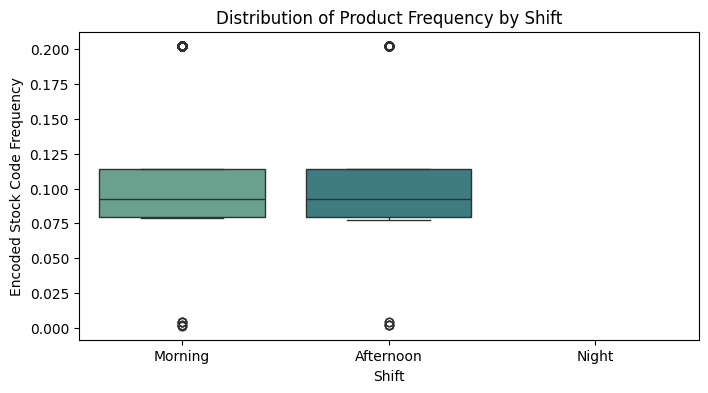

Insight:
The distribution of product frequencies is generally consistent between the Morning and Afternoon shifts, suggesting similar production patterns during these periods.
There seems to be a few outliers indicating that certain product codes are either produced in large volumes or only occasionally.


In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data=injection_df, x='Shift', y='stock_mst_code_encoded',
            order=['Morning','Afternoon','Night'], palette='crest')
plt.title('Distribution of Product Frequency by Shift')
plt.xlabel('Shift')
plt.ylabel('Encoded Stock Code Frequency')
plt.show()

print("Insight:")
print("The distribution of product frequencies is generally consistent between the Morning and Afternoon shifts, suggesting similar production patterns during these periods.")
print("There seems to be a few outliers indicating that certain product codes are either produced in large volumes or only occasionally.")

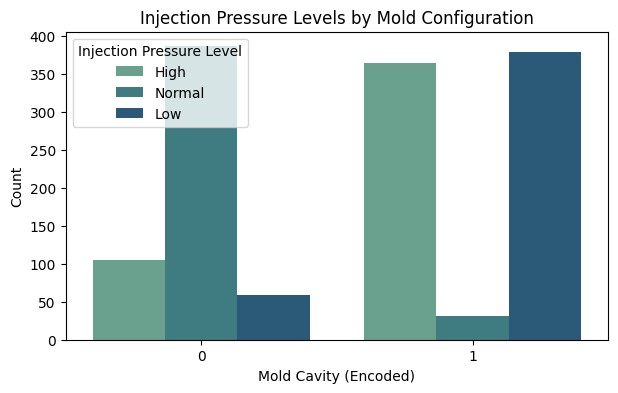

Insight:
The result shows differences in injection pressure distribution between mold configurations
For single-cavity molds (0), most cycles occur under Normal pressure, indicating consistent process stability.
For multi-cavity molds (1), there is a higher occurrence of High and Low pressures, suggesting greater variability in the injection phase.


In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=injection_df, x='MOLD_CAVITY_encoded', hue='PressureLevel_injection',
              palette='crest')
plt.title('Injection Pressure Levels by Mold Configuration')
plt.xlabel('Mold Cavity (Encoded)')
plt.ylabel('Count')
plt.legend(title='Injection Pressure Level')
plt.show()


print("Insight:")
print("The result shows differences in injection pressure distribution between mold configurations")
print("For single-cavity molds (0), most cycles occur under Normal pressure, indicating consistent process stability.")
print("For multi-cavity molds (1), there is a higher occurrence of High and Low pressures, suggesting greater variability in the injection phase.")